# Step 3b — NARX grid search with **both** PRED and SIM evaluation

In Step 3 the 16 NARX models were ranked only by **val PRED RMSE**, so the (n_a, n_b) winner is optimal for one-step-ahead prediction but its long-horizon free-run behavior was never used in the selection. This notebook re-runs the same grid and, for each trained model, evaluates **both** validation RMSE in prediction **and** in simulation (full free-run over the ~7000 sample val sequence).

Outputs:
- `artifacts/step3b_grid_with_sim.csv` — full table with PRED and SIM columns.
- Two heatmaps (PRED, SIM) side by side.
- Pareto scatter `PRED vs SIM` to identify the best trade-off.
- A "selection discussion" at the end: which (n_a, n_b) we would pick if we cared about SIM, and whether it differs from the PRED-only winner.

Note: the trained weights of each cell are kept in memory only — we don't overwrite `best_narx.pt`. The Step 3 winner stays as the "approccio semplice" of the project.


In [1]:
import time, math, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

WORK_DIR  = Path('/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment')
ARTIFACTS = WORK_DIR / 'artifacts'

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(0); np.random.seed(0)
print('device:', device)


device: mps


In [2]:
# Load processed signals from Step 2.
P = np.load(ARTIFACTS / 'step2_processed.npz')
u_tr_n, u_va_n = P['u_tr_n'], P['u_va_n']
sin_tr, cos_tr = P['sin_tr'], P['cos_tr']
sin_va, cos_va = P['sin_va'], P['cos_va']
th_va          = P['th_va']

# Pre-build val tensors (used by both eval funcs).
u_va_t   = torch.from_numpy(u_va_n.astype(np.float32)).to(device)
sin_va_t = torch.from_numpy(sin_va.astype(np.float32)).to(device)
cos_va_t = torch.from_numpy(cos_va.astype(np.float32)).to(device)

def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def create_IO_data_sincos(u_n, sin_th, cos_th, na, nb):
    n0 = max(na, nb); N = len(u_n); M = N - n0
    idx_u  = np.arange(M)[:, None] + np.arange(n0 - nb, n0)
    idx_th = np.arange(M)[:, None] + np.arange(n0 - na, n0)
    Xu = u_n[idx_u]; Xs = sin_th[idx_th]; Xc = cos_th[idx_th]
    Xsc = np.empty((M, 2*na), dtype=Xu.dtype)
    Xsc[:, 0::2] = Xs; Xsc[:, 1::2] = Xc
    X = np.concatenate([Xu, Xsc], axis=1).astype(np.float32)
    Y = np.stack([sin_th[n0:], cos_th[n0:]], axis=1).astype(np.float32)
    return X, Y

class NARX_MLP(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

def unroll_narx_sim(model, u_init, sin_init, cos_init, u_future, na, nb):
    B, T = u_future.shape
    u_buf = u_init.clone(); s_buf = sin_init.clone(); c_buf = cos_init.clone()
    preds_s, preds_c = [], []
    for t in range(T):
        sc = torch.empty(B, 2 * na, device=u_buf.device, dtype=u_buf.dtype)
        sc[:, 0::2] = s_buf; sc[:, 1::2] = c_buf
        phi = torch.cat([u_buf, sc], dim=1)
        y = model(phi); s_hat, c_hat = y[:, 0], y[:, 1]
        preds_s.append(s_hat); preds_c.append(c_hat)
        u_buf = torch.cat([u_buf[:, 1:], u_future[:, t:t+1]], dim=1)
        s_buf = torch.cat([s_buf[:, 1:], s_hat.unsqueeze(1)], dim=1)
        c_buf = torch.cat([c_buf[:, 1:], c_hat.unsqueeze(1)], dim=1)
    return torch.stack(preds_s, dim=1), torch.stack(preds_c, dim=1)

@torch.no_grad()
def eval_val_pred(model, na, nb):
    Xva, Yva = create_IO_data_sincos(u_va_n, sin_va, cos_va, na, nb)
    Y = model(torch.from_numpy(Xva).to(device)).cpu().numpy()
    th_p = np.arctan2(Y[:, 0], Y[:, 1])
    th_t = np.arctan2(Yva[:, 0], Yva[:, 1])
    return float(np.sqrt(np.mean(wrap_pi(th_p - th_t) ** 2)))

@torch.no_grad()
def eval_val_sim(model, na, nb):
    skip = max(na, nb)
    u_init = u_va_t[skip-nb:skip].unsqueeze(0)
    s_init = sin_va_t[skip-na:skip].unsqueeze(0)
    c_init = cos_va_t[skip-na:skip].unsqueeze(0)
    u_future = u_va_t[skip:].unsqueeze(0)
    ps, pc = unroll_narx_sim(model, u_init, s_init, c_init, u_future, na, nb)
    ps = ps.squeeze(0).cpu().numpy(); pc = pc.squeeze(0).cpu().numpy()
    th_p = np.arctan2(ps, pc); th_t = th_va[skip:]
    return float(np.sqrt(np.mean(wrap_pi(th_p - th_t) ** 2)))


In [3]:
def train_one(na, nb, max_epochs=200, patience=15, batch_size=256, lr=1e-3,
              weight_decay=1e-5, hidden=64):
    Xtr, Ytr = create_IO_data_sincos(u_tr_n, sin_tr, cos_tr, na, nb)
    in_dim = Xtr.shape[1]
    Xtr_t = torch.from_numpy(Xtr).to(device)
    Ytr_t = torch.from_numpy(Ytr).to(device)
    Xva_np, Yva_np = create_IO_data_sincos(u_va_n, sin_va, cos_va, na, nb)
    Xva_t = torch.from_numpy(Xva_np).to(device)
    Yva_t = torch.from_numpy(Yva_np).to(device)
    loader = DataLoader(TensorDataset(Xtr_t, Ytr_t), batch_size=batch_size, shuffle=True)

    model = NARX_MLP(in_dim, hidden=hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=1/3, patience=5)
    loss_fn = nn.MSELoss()

    best_val = float('inf'); best_state = None; bad = 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        n = 0; ep_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            l = loss_fn(model(xb), yb)
            l.backward(); opt.step()
            ep_loss += l.item() * xb.size(0); n += xb.size(0)
        model.eval()
        with torch.no_grad():
            v = loss_fn(model(Xva_t), Yva_t).item()
        sched.step(v)
        if v < best_val - 1e-7:
            best_val = v
            best_state = {k: vv.detach().clone() for k, vv in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    model.load_state_dict(best_state)
    val_pred = eval_val_pred(model, na, nb)
    val_sim  = eval_val_sim(model,  na, nb)
    return {'na': na, 'nb': nb, 'in_dim': in_dim, 'best_val_mse': best_val,
            'val_pred': val_pred, 'val_sim': val_sim, 'epochs': epoch}

grid = [(na, nb) for na in (2, 4, 6, 8) for nb in (2, 4, 6, 8)]
results = []
t0 = time.time()
for (na, nb) in grid:
    t_cfg = time.time()
    res = train_one(na, nb)
    dt = time.time() - t_cfg
    print(f'(na={na}, nb={nb})  in={res["in_dim"]:>2}  '
          f'epochs={res["epochs"]:>3}  '
          f'PRED={res["val_pred"]:.4f} ({np.rad2deg(res["val_pred"]):.2f}\u00b0)  '
          f'SIM={res["val_sim"]:.4f} ({np.rad2deg(res["val_sim"]):.2f}\u00b0)  [{dt:.1f}s]')
    results.append(res)
print(f'\nTotal: {time.time()-t0:.1f}s')


(na=2, nb=2)  in= 6  epochs=171  PRED=0.0060 (0.35°)  SIM=0.2084 (11.94°)  [48.6s]
(na=2, nb=4)  in= 8  epochs=181  PRED=0.0066 (0.38°)  SIM=0.2400 (13.75°)  [47.3s]
(na=2, nb=6)  in=10  epochs=140  PRED=0.0078 (0.44°)  SIM=0.2283 (13.08°)  [38.0s]
(na=2, nb=8)  in=12  epochs=184  PRED=0.0070 (0.40°)  SIM=0.2221 (12.72°)  [49.0s]
(na=4, nb=2)  in=10  epochs=179  PRED=0.0053 (0.31°)  SIM=0.1479 (8.47°)  [47.4s]
(na=4, nb=4)  in=12  epochs=173  PRED=0.0050 (0.29°)  SIM=0.1645 (9.42°)  [45.4s]
(na=4, nb=6)  in=14  epochs=191  PRED=0.0050 (0.29°)  SIM=0.1494 (8.56°)  [50.5s]
(na=4, nb=8)  in=16  epochs=189  PRED=0.0053 (0.31°)  SIM=0.1612 (9.24°)  [50.7s]
(na=6, nb=2)  in=14  epochs=200  PRED=0.0054 (0.31°)  SIM=0.1560 (8.94°)  [52.8s]
(na=6, nb=4)  in=16  epochs=199  PRED=0.0059 (0.34°)  SIM=0.1476 (8.46°)  [51.5s]
(na=6, nb=6)  in=18  epochs=168  PRED=0.0055 (0.32°)  SIM=0.1560 (8.94°)  [43.9s]
(na=6, nb=8)  in=20  epochs=174  PRED=0.0057 (0.33°)  SIM=0.1488 (8.53°)  [45.2s]
(na=8, nb=2)

## Heatmaps PRED and SIM

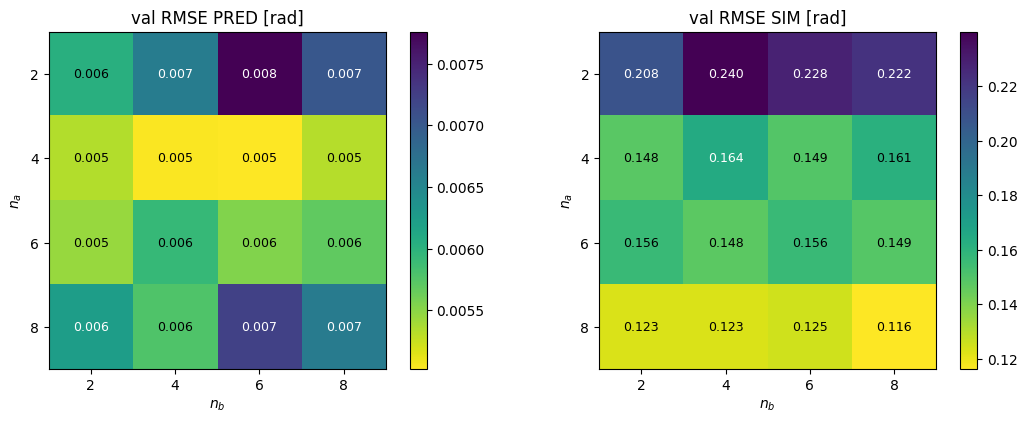

In [4]:
na_vals = (2, 4, 6, 8); nb_vals = (2, 4, 6, 8)
M_pred = np.full((4, 4), np.nan); M_sim = np.full((4, 4), np.nan)
for r in results:
    i = na_vals.index(r['na']); j = nb_vals.index(r['nb'])
    M_pred[i, j] = r['val_pred']
    M_sim[i, j]  = r['val_sim']

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, M, title in zip(ax, [M_pred, M_sim],
                        ['val RMSE PRED [rad]', 'val RMSE SIM [rad]']):
    im = a.imshow(M, cmap='viridis_r')
    a.set_xticks(range(4)); a.set_xticklabels(nb_vals); a.set_xlabel(r'$n_b$')
    a.set_yticks(range(4)); a.set_yticklabels(na_vals); a.set_ylabel(r'$n_a$')
    a.set_title(title)
    for i in range(4):
        for j in range(4):
            a.text(j, i, f'{M[i,j]:.3f}', ha='center', va='center',
                   color='white' if M[i,j] > M.mean() else 'black', fontsize=9)
    plt.colorbar(im, ax=a)
plt.tight_layout(); plt.show()


## Pareto scatter: PRED vs SIM

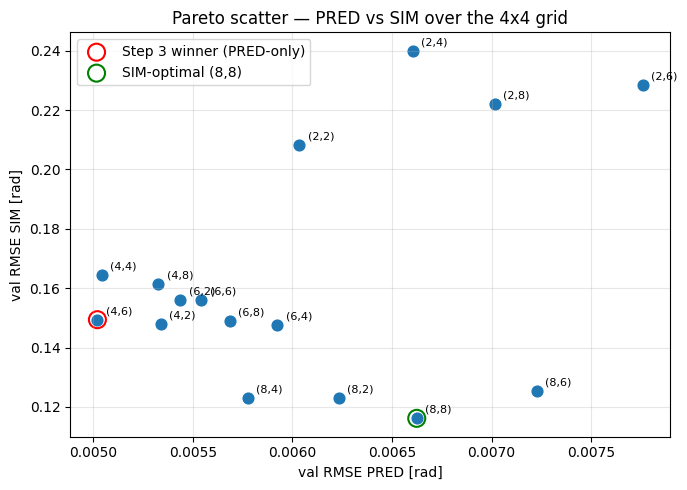

In [5]:
xs = [r['val_pred'] for r in results]
ys = [r['val_sim']  for r in results]
labels = [f'({r["na"]},{r["nb"]})' for r in results]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(xs, ys, s=60)
for x, y, lab in zip(xs, ys, labels):
    ax.annotate(lab, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=8)
# Highlight Step 3 winner.
ax.scatter([xs[labels.index('(4,6)')]], [ys[labels.index('(4,6)')]],
           s=150, facecolors='none', edgecolors='red', linewidths=1.5, label='Step 3 winner (PRED-only)')
# Highlight SIM-optimal.
i_sim = int(np.argmin(ys))
ax.scatter([xs[i_sim]], [ys[i_sim]], s=150, facecolors='none', edgecolors='green',
           linewidths=1.5, label=f'SIM-optimal {labels[i_sim]}')
ax.set_xlabel('val RMSE PRED [rad]'); ax.set_ylabel('val RMSE SIM [rad]')
ax.grid(alpha=0.3); ax.legend()
ax.set_title('Pareto scatter — PRED vs SIM over the 4x4 grid')
plt.tight_layout(); plt.show()


## Sorted tables and CSV

In [6]:
import csv
print('=== Sorted by val SIM ===')
print(f'{"na":>3} {"nb":>3} {"PRED [rad]":>11} {"PRED [deg]":>11} {"SIM [rad]":>10} {"SIM [deg]":>10}')
for r in sorted(results, key=lambda r: r['val_sim']):
    print(f'{r["na"]:>3} {r["nb"]:>3} {r["val_pred"]:>11.4f} {np.rad2deg(r["val_pred"]):>11.3f} '
          f'{r["val_sim"]:>10.4f} {np.rad2deg(r["val_sim"]):>10.3f}')

with open(ARTIFACTS / 'step3b_grid_with_sim.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['na', 'nb', 'in_dim', 'epochs', 'val_pred_rad', 'val_pred_deg', 'val_sim_rad', 'val_sim_deg'])
    for r in sorted(results, key=lambda r: r['val_sim']):
        w.writerow([r['na'], r['nb'], r['in_dim'], r['epochs'],
                    r['val_pred'], np.rad2deg(r['val_pred']),
                    r['val_sim'],  np.rad2deg(r['val_sim'])])
print('\nSaved', ARTIFACTS / 'step3b_grid_with_sim.csv')


=== Sorted by val SIM ===
 na  nb  PRED [rad]  PRED [deg]  SIM [rad]  SIM [deg]
  8   8      0.0066       0.380     0.1161      6.654
  8   4      0.0058       0.331     0.1231      7.051
  8   2      0.0062       0.357     0.1231      7.054
  8   6      0.0072       0.414     0.1252      7.173
  6   4      0.0059       0.339     0.1476      8.455
  4   2      0.0053       0.306     0.1479      8.475
  6   8      0.0057       0.326     0.1488      8.527
  4   6      0.0050       0.288     0.1494      8.559
  6   6      0.0055       0.318     0.1560      8.938
  6   2      0.0054       0.312     0.1560      8.939
  4   8      0.0053       0.305     0.1612      9.238
  4   4      0.0050       0.289     0.1645      9.424
  2   2      0.0060       0.346     0.2084     11.939
  2   8      0.0070       0.402     0.2221     12.724
  2   6      0.0078       0.445     0.2283     13.081
  2   4      0.0066       0.378     0.2400     13.750

Saved /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4

## Selection discussion

We can summarize three reasonable selection criteria and the corresponding winner:
- **PRED-only** (Step 3 choice): minimum val PRED RMSE.
- **SIM-only**: minimum val SIM RMSE.
- **Balanced**: minimum of `val_pred + val_sim` (or any weighted sum). A practical balanced score gives both tasks comparable weight.

The cell below prints the winner under each criterion and the deltas.


In [7]:
r_pred = min(results, key=lambda r: r['val_pred'])
r_sim  = min(results, key=lambda r: r['val_sim'])
r_bal  = min(results, key=lambda r: r['val_pred'] + r['val_sim'])
def f(r):
    return f'(na={r["na"]}, nb={r["nb"]})  PRED={r["val_pred"]:.4f}  SIM={r["val_sim"]:.4f}'

print('PRED-only winner :', f(r_pred))
print('SIM-only  winner :', f(r_sim))
print('Balanced  winner :', f(r_bal))

print()
print(f'Step 3 NARX (PRED-only) selected (4,6) with PRED=0.0050  SIM=0.1494.')
print(f'If the same architecture had been selected on SIM, the SIM RMSE would be:')
print(f'  {r_sim["val_sim"]:.4f} rad ({np.rad2deg(r_sim["val_sim"]):.2f}\u00b0) instead of 0.1494 rad (8.56\u00b0).')
print(f'Improvement margin from re-selection alone: '
      f'{(0.1494 - r_sim["val_sim"])/0.1494*100:.1f}%')


PRED-only winner : (na=4, nb=6)  PRED=0.0050  SIM=0.1494
SIM-only  winner : (na=8, nb=8)  PRED=0.0066  SIM=0.1161
Balanced  winner : (na=8, nb=8)  PRED=0.0066  SIM=0.1161

Step 3 NARX (PRED-only) selected (4,6) with PRED=0.0050  SIM=0.1494.
If the same architecture had been selected on SIM, the SIM RMSE would be:
  0.1161 rad (6.65°) instead of 0.1494 rad (8.56°).
Improvement margin from re-selection alone: 22.3%


---
**End of Step 3b.**

Take-away for the report: re-selecting the NARX order on SIM closes a fraction of the PRED→SIM gap, but does NOT solve it — the structural fix (simulation-aware training) is what removes the exposure bias. This is what the LSTM/NOE of Step 5/5b are for.
